# Activity evolution & R/W rate: E5 UNIX Hosts vs. HPC login node

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from provenance_explorer.analysis.activity_realism.activity_evolution.cmdline_normalization import normalize
from provenance_explorer.plotting.config import apply_style, palette
from provenance_explorer.registry.registry_all import CACHE_ROOT, FIGURES_ROOT
from provenance_explorer.utils.time_conversion import ns_timestamp_to_datetime

apply_style()
_pal = palette()

BIN_WIDTH_NS = 5 * 60 * 1_000_000_000
BIN_WIDTH_S = BIN_WIDTH_NS / 1e9
ROLL_BINS = 6  # 6 * 5 min = 30 min

TZ_DARPA = timezone(timedelta(hours=-4))  # capture in UTC-4
TZ_HPC = timezone(timedelta(hours=1)) # HPC filens are CET

## Series configuration

In [ ]:
@dataclass
class Series:
    label: str
    ds: str
    subds: str
    host_id: str | None
    tz: timezone
    ledger_path: Path
    events_path: Path
    rw_event_types: tuple[str, ...]

SERIES: list[Series] = [
    Series(
        label="E5 Cadets #3",
        ds="e5", subds="cadets",
        host_id="CB02303B-654E-11E9-A80C-6C2B597E484C",
        tz=TZ_DARPA,
        ledger_path=CACHE_ROOT / "activity_evolution_plot/e5/cadets/activity_evolution.parquet",
        events_path=CACHE_ROOT / "events_per_host_plot/e5/cadets/events_per_host.parquet",
        rw_event_types=("EVENT_READ", "EVENT_WRITE"),
    ),
    Series(
        label="E5 Theia #2",
        ds="e5", subds="theia",
        host_id="C75CAC93-0BE3-5D8A-9540-A1F43574DE25",
        tz=TZ_DARPA,
        ledger_path=CACHE_ROOT / "activity_evolution_plot/e5/theia/activity_evolution.parquet",
        events_path=CACHE_ROOT / "events_per_host_plot/e5/theia/events_per_host.parquet",
        rw_event_types=("EVENT_READ", "EVENT_WRITE"),
    ),
    Series(
        label="E5 Trace #2",
        ds="e5", subds="trace",
        host_id="DF4AF963-C31C-DAFC-B5C6-D86F33322775",
        tz=TZ_DARPA,
        ledger_path=CACHE_ROOT / "activity_evolution_plot/e5/trace/activity_evolution.parquet",
        events_path=CACHE_ROOT / "events_per_host_plot/e5/trace/events_per_host.parquet",
        rw_event_types=("EVENT_READ", "EVENT_WRITE"),
    ),
    Series(
        label="HPC Login",
        ds="hpc", subds="login",
        host_id=None,
        tz=TZ_HPC,
        ledger_path=CACHE_ROOT / "hpc/activity_evolution_ledger.parquet",
        events_path=CACHE_ROOT / "hpc/event_counts.parquet",
        rw_event_types=("SYSCALL_READ", "SYSCALL_WRITE"),
    ),
]

COLORS = {s.label: _pal[i % len(_pal)] for i, s in enumerate(SERIES)}

E5 Cadets #3    ledger=True  events=True
E5 Theia #2     ledger=True  events=True
E5 Trace #2     ledger=True  events=True
HPC Login       ledger=True  events=True


## saturation curves

In [36]:
def saturation_unit_square(ledger: pd.DataFrame, ds: str, subds: str) -> pd.DataFrame:
    df = ledger.copy()
    df["normalised_cmdline"] = df["normalised_cmdline"].astype("string").apply(
        lambda c: normalize(c, ds, subds)
    )
    df = df.groupby("normalised_cmdline", as_index=False).agg(
        first_seen_ns=("first_seen_ns", "min"),
    )
    if df.empty:
        return pd.DataFrame({"x": [], "y": []})

    bin_ns = (df["first_seen_ns"].astype("int64") // BIN_WIDTH_NS) * BIN_WIDTH_NS
    bins, counts = np.unique(bin_ns.values, return_counts=True)
    cum = np.cumsum(counts).astype(float)

    if len(bins) <= 1:
        return pd.DataFrame({"x": [0.0, 1.0], "y": [1.0, 1.0]})

    x = (bins - bins[0]) / (bins[-1] - bins[0])
    y = cum / cum[-1]
    return pd.DataFrame({"x": x, "y": y})


saturation_curves: dict[str, pd.DataFrame] = {}
for s in SERIES:
    led = pd.read_parquet(s.ledger_path)
    if s.host_id is not None:
        led = led[led["host_id"] == s.host_id]
    saturation_curves[s.label] = saturation_unit_square(led, s.ds, s.subds)
    print(f"{s.label:<14}  unique cmdlines={len(led):>6}  bins={len(saturation_curves[s.label])}")

E5 Cadets #3    unique cmdlines=  2461  bins=88
E5 Theia #2     unique cmdlines=  3807  bins=208
E5 Trace #2     unique cmdlines= 26438  bins=248
HPC Login       unique cmdlines=   789  bins=243


## R/W rate, weekday-aligned

In [ ]:
def _anchor_monday(dt: datetime) -> datetime:
    """Monday 00:00 in dt's tzinfo"""
    d = dt.replace(hour=0, minute=0, second=0, microsecond=0)
    return d - timedelta(days=d.weekday())

def rw_rate_curve(events: pd.DataFrame, host_id: str | None,
                  rw_types: tuple[str, ...], tz: timezone) -> pd.DataFrame:
    df = events
    if host_id is not None:
        df = df[df["host_id"] == host_id]
    df = df[df["event_type"].isin(rw_types)]
    if df.empty:
        return pd.DataFrame({"hours_from_anchor": [], "rate": []})

    binned = df.groupby("time_bin_ns", as_index=False)["count"].sum()

    # reindex onto full bin grid so gap bins are 0
    t_min = int(binned["time_bin_ns"].min())
    t_max = int(binned["time_bin_ns"].max())
    full_grid = np.arange(t_min, t_max + BIN_WIDTH_NS, BIN_WIDTH_NS, dtype="int64")
    binned = (
        binned.set_index("time_bin_ns").reindex(full_grid, fill_value=0).rename_axis("time_bin_ns").reset_index()
    )

    rate_raw = binned["count"].astype("float64") / BIN_WIDTH_S
    rate = rate_raw.rolling(ROLL_BINS, center=True, min_periods=1).mean()

    first_dt = ns_timestamp_to_datetime(int(binned["time_bin_ns"].iloc[0]), tz=tz)
    anchor = _anchor_monday(first_dt)
    hours = np.array([
        (ns_timestamp_to_datetime(int(t), tz=tz) - anchor).total_seconds() / 3600.0
        for t in binned["time_bin_ns"]
    ])
    return pd.DataFrame({"hours_from_anchor": hours, "rate": rate.values})


rw_curves: dict[str, pd.DataFrame] = {}
for s in SERIES:
    ev = pd.read_parquet(s.events_path)
    rw_curves[s.label] = rw_rate_curve(ev, s.host_id, s.rw_event_types, s.tz)
    c = rw_curves[s.label]
    if not c.empty:
        print(f"{s.label:<14}  bins={len(c):>5}  span={c['hours_from_anchor'].min():.1f}h..{c['hours_from_anchor'].max():.1f}h  peak={c['rate'].max():,.1f} ev/s")
    else:
        print(f"{s.label:<14}  empty")

E5 Cadets #3    bins= 2990  span=32.8h..281.8h  peak=1,474.2 ev/s
E5 Theia #2     bins= 2985  span=33.3h..282.0h  peak=30,493.9 ev/s
E5 Trace #2     bins= 2981  span=33.2h..281.6h  peak=2,039.9 ev/s
HPC Login       bins= 1151  span=109.7h..205.5h  peak=124,481.9 ev/s


## Activity evolution

wrote /mnt/vast-nhr/home/j.rieling/u20606/provenance-benchmark-explorer/img/figures/activity_evolution_vs_hpc/activity_evolution_unit_square.pdf


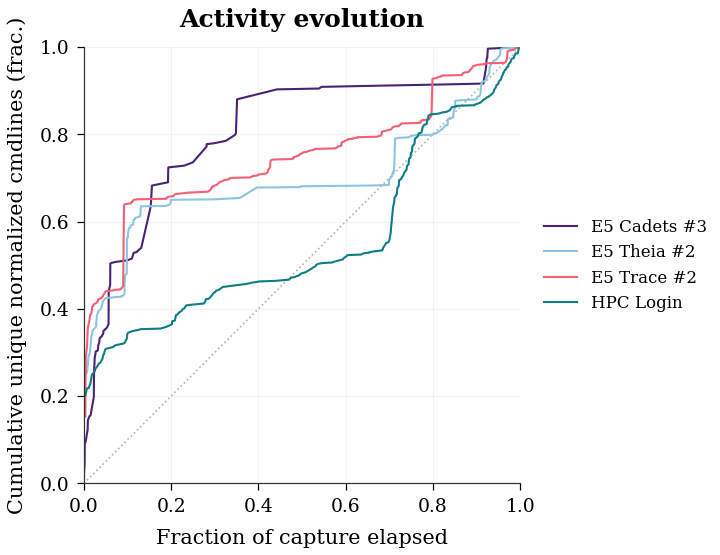

In [ ]:
fig1, ax1 = plt.subplots(figsize=(5.0, 5.0))

ax1.plot([0, 1], [0, 1], color="0.7", linestyle=":", linewidth=0.8,)
for s in SERIES:
    c = saturation_curves[s.label]
    if c.empty:
        continue
    ax1.plot(c["x"], c["y"], label=s.label, color=COLORS[s.label], linewidth=1.0)

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_aspect("equal")
ax1.set_xlabel("Fraction of capture elapsed")
ax1.set_ylabel("Cumulative unique normalized cmdlines (frac.)")
# ax1.set_title("Activity evolution")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig1.tight_layout()

out_dir = Path(FIGURES_ROOT) / "activity_evolution_vs_hpc"
out_dir.mkdir(parents=True, exist_ok=True)
fig1.savefig(out_dir / "activity_evolution_unit_square.pdf", bbox_inches="tight")
fig1.savefig(out_dir / "activity_evolution_unit_square.png", dpi=200, bbox_inches="tight")
print(f"wrote {out_dir / 'activity_evolution_unit_square.pdf'}")
plt.show()

## Figure 2 — Read/write rate, weekday-aligned

wrote /mnt/vast-nhr/home/j.rieling/u20606/provenance-benchmark-explorer/img/figures/activity_evolution_vs_hpc/rw_rate_weekday.pdf


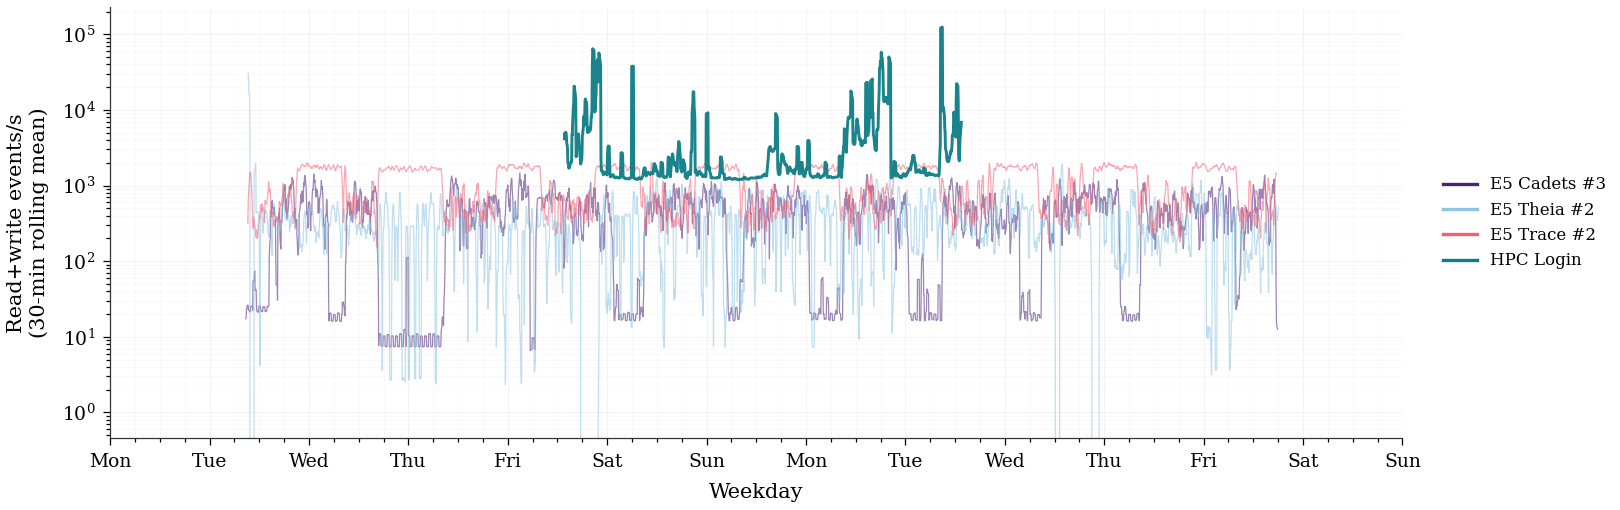

In [ ]:
def _weekday_axis(ax, max_hours: float) -> None:
    weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    n_days = int(np.ceil(max_hours / 24)) + 1
    ticks = np.arange(0, n_days * 24 + 1, 24)
    labels = [weekdays[(int(t) // 24) % 7] for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(6))
    ax.set_xlim(0, n_days * 24)


fig2, ax2 = plt.subplots(figsize=(11, 3.6))

DARPA_KW = dict(linewidth=0.6, alpha=0.55)
HPC_KW = dict(linewidth=1.4, alpha=0.95)

ordered = [s for s in SERIES if s.label != "HPC Login"] + [
    s for s in SERIES if s.label == "HPC Login"
]
for s in ordered:
    c = rw_curves[s.label]
    if c.empty:
        continue
    is_hpc = s.label == "HPC Login"
    kw = HPC_KW if is_hpc else DARPA_KW
    ax2.plot(
        c["hours_from_anchor"], c["rate"],
        label=s.label, color=COLORS[s.label],
        zorder=3 if is_hpc else 2,
        **kw,
    )

max_hours = max(
    (c["hours_from_anchor"].max() for c in rw_curves.values() if not c.empty),
    default=168.0,
)
ax2.set_yscale("log")
ax2.set_ylabel("Read+write events/s\n(30-min rolling mean)")
ax2.set_xlabel("Weekday")
# ax2.set_title("Read/write event rate, weekday-aligned")
ax2.grid(True, which="major", alpha=0.3)
ax2.grid(True, which="minor", alpha=0.12)
_weekday_axis(ax2, max_hours)

leg = ax2.legend(
    fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False,
)
for line in leg.get_lines():
    line.set_alpha(1.0)
    line.set_linewidth(1.6)

fig2.tight_layout()

out_dir = Path(FIGURES_ROOT) / "activity_evolution_vs_hpc"
out_dir.mkdir(parents=True, exist_ok=True)
fig2.savefig(out_dir / "rw_rate_weekday.pdf", bbox_inches="tight")
fig2.savefig(out_dir / "rw_rate_weekday.png", dpi=200, bbox_inches="tight")
print(f"wrote {out_dir / 'rw_rate_weekday.pdf'}")
plt.show()